In [104]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
profiles = pd.read_csv('profiles.csv')

In [5]:
profiles.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [6]:
list(profiles.columns)

['age',
 'body_type',
 'diet',
 'drinks',
 'drugs',
 'education',
 'essay0',
 'essay1',
 'essay2',
 'essay3',
 'essay4',
 'essay5',
 'essay6',
 'essay7',
 'essay8',
 'essay9',
 'ethnicity',
 'height',
 'income',
 'job',
 'last_online',
 'location',
 'offspring',
 'orientation',
 'pets',
 'religion',
 'sex',
 'sign',
 'smokes',
 'speaks',
 'status']

In [9]:
print('number of columns: ', profiles.body_type.nunique())
print('categories: ', profiles.body_type.unique())

number of columns:  12
categories:  <StringArray>
['a little extra',        'average',           'thin',       'athletic',
            'fit',              nan,         'skinny',          'curvy',
   'full figured',         'jacked', 'rather not say',        'used up',
     'overweight']
Length: 13, dtype: str


In [73]:
print(profiles["body_type"].value_counts().to_frame())

                count
body_type            
average         14652
fit             12711
athletic        11819
thin             4711
curvy            3924
a little extra   2629
skinny           1777
other            1418
full figured     1009


In [54]:
rare = ["overweight", "jacked", "used up", "rather not say"]

profiles["body_type"] = profiles["body_type"].replace(rare, "other")

<Axes: xlabel='count', ylabel='sex'>

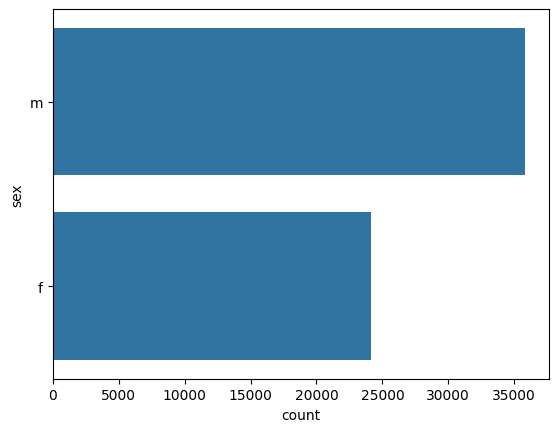

In [12]:
sns.countplot(data = profiles, y = 'sex')

<Axes: xlabel='count', ylabel='diet'>

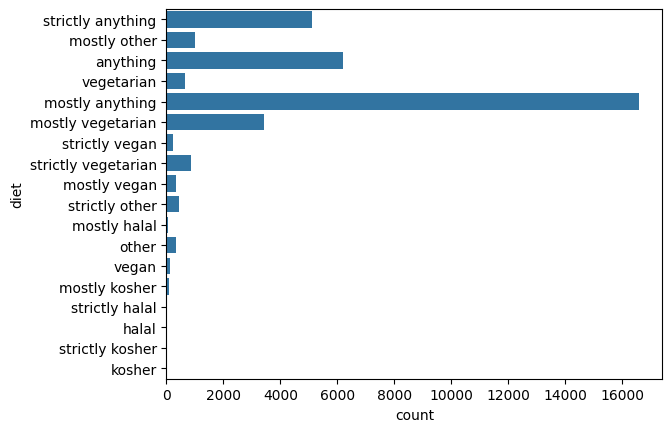

In [13]:
sns.countplot(data = profiles, y = 'diet')

<Axes: xlabel='count', ylabel='smokes'>

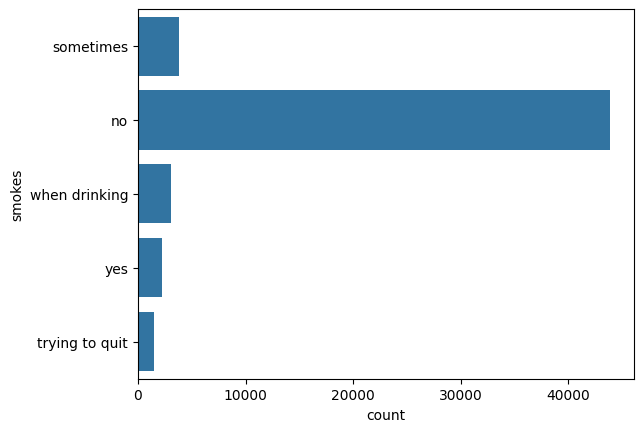

In [14]:
sns.countplot(data = profiles, y = 'smokes')

<Axes: xlabel='count', ylabel='drugs'>

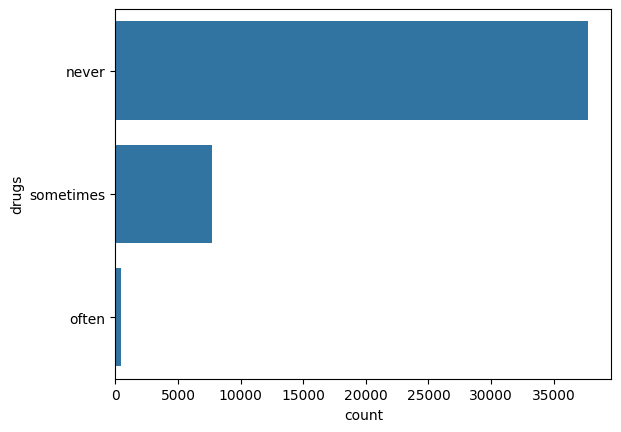

In [15]:
sns.countplot(data = profiles, y = 'drugs')

<Axes: xlabel='count', ylabel='drinks'>

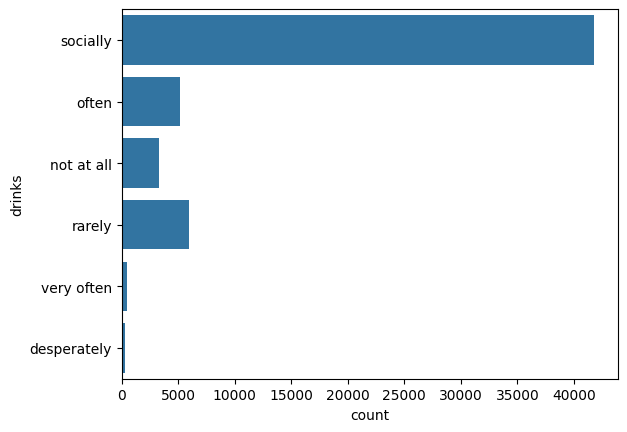

In [16]:
sns.countplot(data = profiles, y = 'drinks')

In [56]:
profiles_train = profiles[['body_type', 'sex', 'drugs', 'drinks', 'smokes', 'diet']].copy()
profiles_train = profiles_train[profiles_train['body_type'].notna()]
categorical_columns = ['sex', 'drugs', 'drinks', 'smokes', 'diet']
profiles_train = pd.get_dummies(profiles_train, columns=categorical_columns)
X = profiles_train.drop('body_type', axis=1)
y = profiles_train['body_type']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
classifier = KNeighborsClassifier(n_neighbors = 5)
for k in [3, 5, 7, 9, 11, 15]:
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train_scaled, y_train)
    pred = classifier.predict(X_test_scaled)
    print(f"k={k}: {accuracy_score(y_test, pred):.3f}")

k=3: 0.224
k=5: 0.235
k=7: 0.246
k=9: 0.251
k=11: 0.266
k=15: 0.279


In [60]:
classifier.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [61]:
y_pred_classifier = classifier.predict(X_test_scaled)

In [62]:
print('Classifier accuracy: ', accuracy_score(y_test, y_pred_classifier))

Classifier accuracy:  0.23513266239707228


In [89]:
log_reg = LogisticRegression(max_iter=1000)

In [90]:
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [91]:
y_log_reg_pred = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_log_reg_pred))

Logistic Regression Accuracy: 0.3000914913083257


In [99]:
tree = DecisionTreeClassifier(random_state=42)

In [100]:
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [101]:
y_pred_tree = tree.predict(X_test)

In [102]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.2858188472095151


In [111]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.1919487648673376


In [115]:
results = pd.DataFrame({"Model": ["KNN", "Logistic Regression", "Decision Tree", "Random Forest"], "Accuracy": [accuracy_score(y_test, y_pred_classifier), accuracy_score(y_test, y_log_reg_pred), accuracy_score(y_test, y_pred_tree), accuracy_score(y_test, y_pred_rf)]})
print(results)

                 Model  Accuracy
0                  KNN  0.235133
1  Logistic Regression  0.300091
2        Decision Tree  0.285819
3        Random Forest  0.191949


In [116]:
print(classification_report(y_test, y_pred_classifier))

                precision    recall  f1-score   support

a little extra       0.04      0.10      0.06       526
      athletic       0.27      0.51      0.35      2364
       average       0.29      0.26      0.27      2930
         curvy       0.22      0.11      0.15       785
           fit       0.24      0.15      0.18      2542
  full figured       0.08      0.00      0.01       202
         other       0.11      0.02      0.04       284
        skinny       0.14      0.01      0.02       355
          thin       0.11      0.06      0.08       942

      accuracy                           0.24     10930
     macro avg       0.17      0.14      0.13     10930
  weighted avg       0.23      0.24      0.21     10930



<Axes: xlabel='count', ylabel='body_type'>

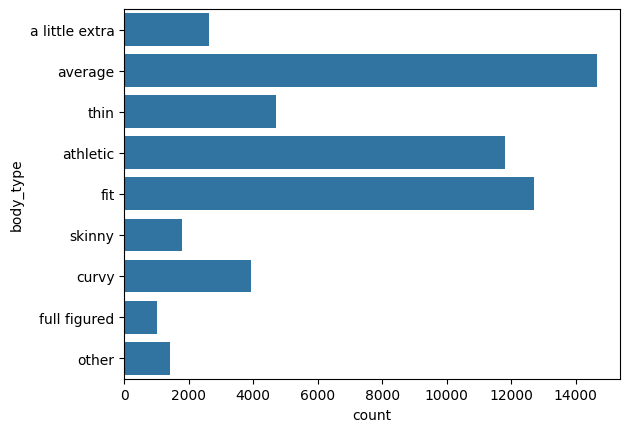

In [74]:
sns.countplot(data = profiles, y = 'body_type')

<Axes: xlabel='height', ylabel='body_type'>

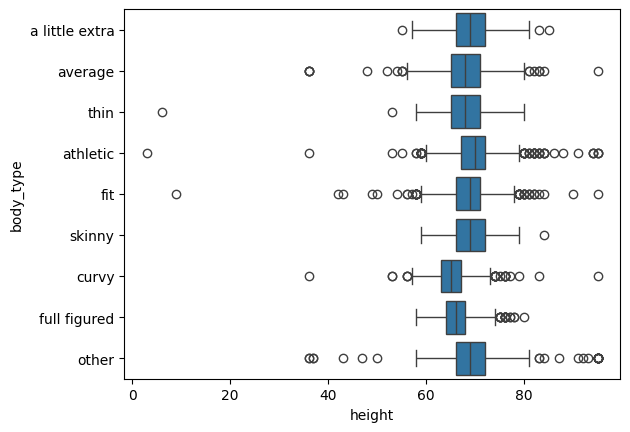

In [76]:
sns.boxplot(data = profiles, x = 'height', y = 'body_type')

<Axes: xlabel='drinks', ylabel='body_type'>

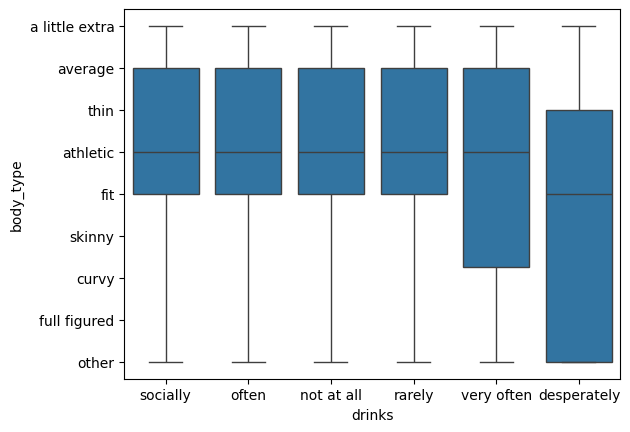

In [77]:
sns.boxplot(data = profiles, x = 'drinks', y = 'body_type')

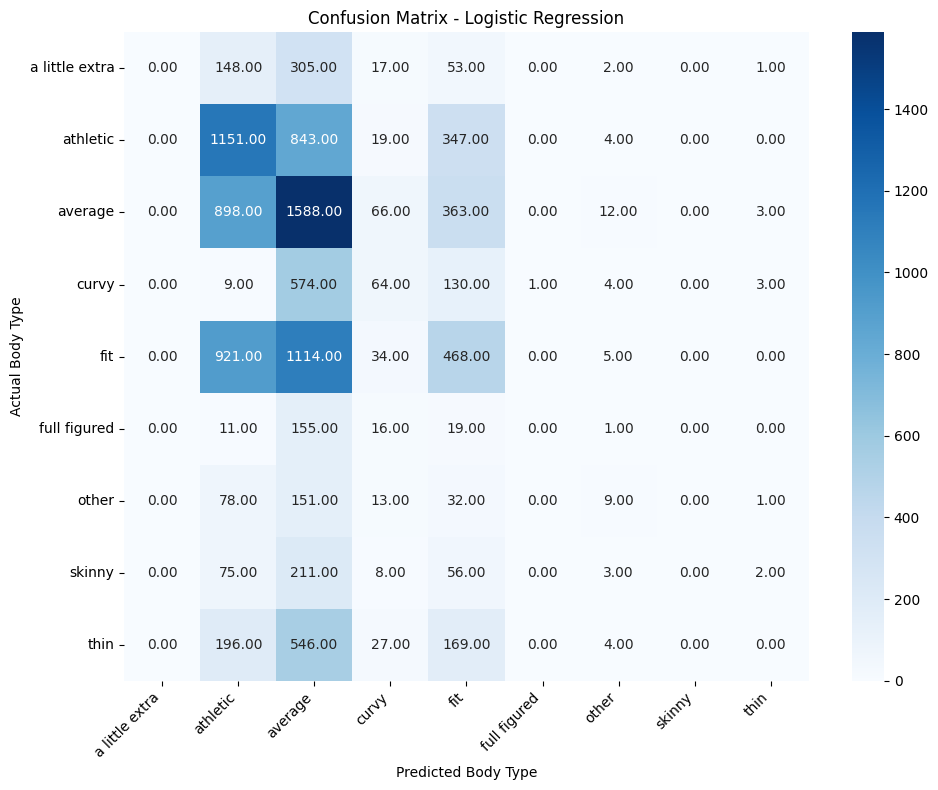

In [119]:
cm_norm = confusion_matrix(y_test, y_log_reg_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Body Type")
plt.ylabel("Actual Body Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [124]:
log_reg = LogisticRegression(max_iter=1000, class_weight = 'balanced')

In [127]:
log_reg.fit(X_train_scaled, y_train)
y_log_reg_balanced_pred = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_log_reg_pred))

Logistic Regression Accuracy: 0.1978956999085087


In [128]:
print(classification_report(y_test, y_log_reg_balanced_pred))

                precision    recall  f1-score   support

a little extra       0.08      0.20      0.12       526
      athletic       0.33      0.52      0.41      2364
       average       0.30      0.01      0.01      2930
         curvy       0.18      0.76      0.29       785
           fit       0.31      0.03      0.06      2542
  full figured       0.05      0.19      0.08       202
         other       0.07      0.15      0.10       284
        skinny       0.06      0.14      0.09       355
          thin       0.06      0.00      0.01       942

      accuracy                           0.20     10930
     macro avg       0.16      0.22      0.13     10930
  weighted avg       0.25      0.20      0.14     10930



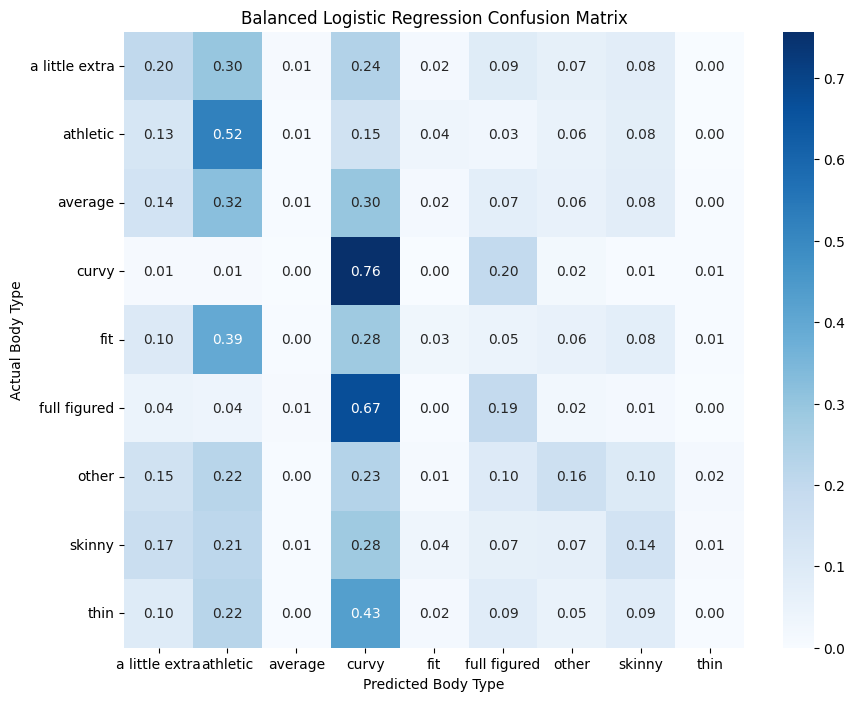

In [129]:
log_reg_balanced = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
log_reg_balanced.fit(X_train, y_train)
y_pred_balanced = log_reg_balanced.predict(X_test)
cm = confusion_matrix(y_test, y_pred_balanced, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=log_reg_balanced.classes_, yticklabels=log_reg_balanced.classes_)
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Body Type")
plt.ylabel("Actual Body Type")
plt.show()